# Aprendizaje no supervisado

## Conglomerados (Clustering)

- Se presentan los conceptos básicos de aprendizaje no supervisado mediante nociones de disimilitud y similitud.

**Ejemplo:** Consideremos el conjunto de datos *iris dataset*, donde la especie de cada instancia (es decir, su clase) se representa con un marcador diferente:

In [ ]:
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt
import numpy as np

data = load_iris()
X    = data.data
y    = data.target
data.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

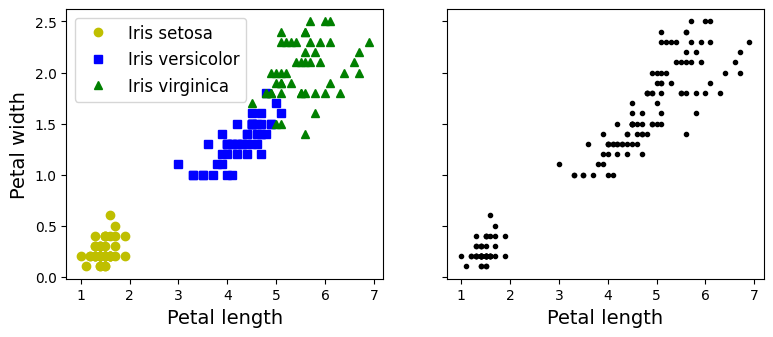

In [ ]:
plt.figure(figsize=(9, 3.5))

plt.subplot(121)
plt.plot(X[y==0, 2], X[y==0, 3], "yo", label="Iris setosa")
plt.plot(X[y==1, 2], X[y==1, 3], "bs", label="Iris versicolor")
plt.plot(X[y==2, 2], X[y==2, 3], "g^", label="Iris virginica")
plt.xlabel("Petal length", fontsize=14)
plt.ylabel("Petal width", fontsize=14)
plt.legend(fontsize=12)

plt.subplot(122)
plt.scatter(X[:, 2], X[:, 3], c="k", marker=".")
plt.xlabel("Petal length", fontsize=14)
plt.tick_params(labelleft=False)

#save_fig("classification_vs_clustering_plot")
plt.show()

- **Figura de la izquierda:** Es un conjunto de datos etiquetado, para el cual los algoritmos de clasificación como Regresión logística, SVM o clasificadores de bosque aleatorio son muy adecuados.
- **Figura de la derecha:** Tenemos el mismo conjunto de datos, pero sin las etiquetas, por lo que ya no puede usar un algoritmo de clasificación.

- Los algoritmos de conglomerados (clustering) buscan extraer grupos homogeneos de datos usando solo las características de entrada.

- **NOTA:** No existe una definición universal de lo que es un *clúster*: depende del contexto, diferentes algoritmos capturarán diferentes tipos de clústeres.

- Algunos algoritmos buscan instancias centradas alrededor de un punto particular, llamado *centroide*. Otros buscan *regiones continuas de instancias densamente empaquetadas*: estos grupos pueden tomar cualquier forma.

## K-means

Dado un conjunto de datos no supervisado:
\begin{equation}
X = \{ \mathbf{x}_1, \mathbf{x}_2, \ldots, \mathbf{x}_n \}, \quad \mathbf{x}_i \in \mathbb{R}^P
\end{equation}

El problema de optimización del algoritmo K-means, para agrupar los datos de entrada en $K$ grupos disjuntos, se puede definir como:

\begin{align}
\hat{\boldsymbol{\mu}}_k =& \arg\min_{\boldsymbol{\mu}_k} \sum_{k=1}^{K} \sum_{\mathbf{x} \in C_k} \|\mathbf{x} - \boldsymbol{\mu}_k\|^2\\
\text{s.t.} & \quad C_k = \left\{\mathbf{x}_n : k=\min_{j}\|\mathbf{x} - \boldsymbol{\mu}_k\|\right\} \\
& \quad C_k \cap C_{k'} = \emptyset
\end{align}

donde el centro se define como:

\begin{equation}
\boldsymbol{\mu}_k = \frac{1}{|C_k|} \sum_{\mathbf{x} \in C_k} \mathbf{x}
\end{equation}

Y la actualización de los mismos depende de:

\begin{equation}
\boldsymbol{\mu}_k^{(t+1)} = \frac{1}{|C_k^{(t)}|} \sum_{\mathbf{x} \in C_k^{(t)}} \mathbf{x}
\end{equation}

**Ejemplo:** Consideremos un conjunto de datos sin etiqueta representado por $5$ *blobs* de instancias/muestras.

In [ ]:
from sklearn.datasets import make_blobs

blob_centers = np.array(
    [[ 0.6,  2.3],
     [-1.5 ,  2.3],
     [-2.8,  2],
     [-2.8,  2.8],
     [-2.8,  1.3]])
blob_std = np.array([0.4, 0.3, 0.1, 0.1, 0.1])
X, y     = make_blobs(n_samples=2000, centers=blob_centers,
                  cluster_std=blob_std, random_state=7)


X_ = X

Ahora observemos los *blobs*:

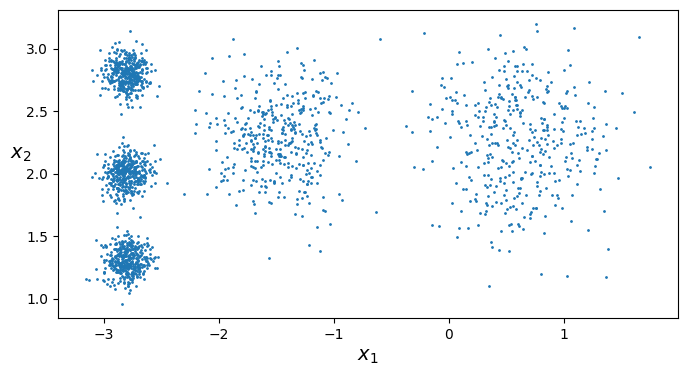

In [ ]:
def plot_clusters(X, y=None):
    plt.scatter(X[:, 0], X[:, 1], c=y, s=1)
    plt.xlabel("$x_1$", fontsize=14)
    plt.ylabel("$x_2$", fontsize=14, rotation=0)

plt.figure(figsize=(8, 4))
plot_clusters(X)
#save_fig("blobs_plot")
plt.show()

### Ajuste y predicción

- Vamos a entrenar un *clustering K-Means* en este conjunto de datos.

- **Intentaremos encontrar el centro de cada *blob* y asignar cada instancia al *blob* más cercano**:

In [ ]:
from sklearn.cluster import KMeans
k      = 5
kmeans = KMeans(n_clusters=k, random_state=42, init='k-means++')
y_pred = kmeans.fit_predict(X)

- Tengamos en cuenta que debemos especificar el número de clústeres $k$ que debe encontrar el algoritmo.

- En este caso, cada instancia fue asignada a uno de los 5 grupos.

- En el contexto de la agrupación, **la etiqueta de una instancia es el índice de la agrupación a la que el algoritmo asigna esta instancia**.

- No debe confundirse con las etiquetas de clase en clasificación.

- *KMeans* conserva una copia de las etiquetas de las instancias en las que se entrenó, disponible a través de la variable *labels_ instance*:

In [ ]:
y_pred

array([1, 1, 4, ..., 3, 4, 1], dtype=int32)

In [ ]:
y_pred is kmeans.labels_

True

También podemos echar un vistazo a los 5 centroides que encontró el algoritmo:

In [ ]:
kmeans.cluster_centers_

array([[ 0.34187422,  2.22617479],
       [-2.80236767,  1.6483813 ],
       [-1.4714462 ,  2.28524725],
       [-2.79255053,  2.79105781],
       [ 0.95102961,  2.29714359]])

Por supuesto, podemos asignar fácilmente nuevas instancias al clúster cuyo centroide es el más cercano:

In [ ]:
X_new = np.array([[0, 2], [3, 2], [-3, 3], [-3, 2.5]])
kmeans.predict(X_new)

array([0, 4, 3, 3], dtype=int32)

### Fronteras de decisión

Tracemos los **límites de decisión del modelo**. Esto nos da un *diagrama de Voronoi*:

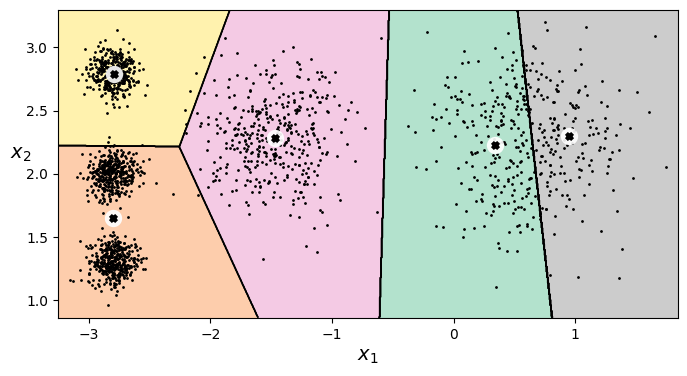

In [ ]:
def plot_data(X):
    plt.plot(X[:, 0], X[:, 1], 'k.', markersize=2)

def plot_centroids(centroids, weights=None, circle_color='w', cross_color='k'):
    if weights is not None:
        centroids = centroids[weights > weights.max() / 10]
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='o', s=20, linewidths=8,
                color=circle_color, zorder=10, alpha=0.9)
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='x', s=20, linewidths=3,
                color=cross_color, zorder=11, alpha=1)

def plot_decision_boundaries(clusterer, X, resolution=1000, show_centroids=True,
                             show_xlabels=True, show_ylabels=True):
    mins = X.min(axis=0) - 0.1
    maxs = X.max(axis=0) + 0.1
    xx, yy = np.meshgrid(np.linspace(mins[0], maxs[0], resolution),
                         np.linspace(mins[1], maxs[1], resolution))
    Z = clusterer.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]),
                cmap="Pastel2")
    plt.contour(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]),
                linewidths=1, colors='k')
    plot_data(X)
    if show_centroids:
        plot_centroids(clusterer.cluster_centers_)

    if show_xlabels:
        plt.xlabel("$x_1$", fontsize=14)
    else:
        plt.tick_params(labelbottom=False)
    if show_ylabels:
        plt.ylabel("$x_2$", fontsize=14, rotation=0)
    else:
        plt.tick_params(labelleft=False)

plt.figure(figsize=(8, 4))
plot_decision_boundaries(kmeans, X)
#save_fig("voronoi_plot")
plt.show()

- La gran mayoría de las instancias estan claramente asignadas al grupo apropiado,**pero algunas instancias probablemente estaban mal etiquetadas** (especialmente cerca del límite entre el grupo superior izquierdo y el grupo central).
- De hecho, el algoritmo **K-Means no se comporta muy bien cuando los *blobs* tienen diámetros muy diferentes**, ya que lo único que le importa al asignar una instancia a un clúster es la distancia al centro.

### Hard Clustering vs Soft Clustering

- En lugar de asignar cada instancia a un solo clúster, lo que se denomina *hard clustering*, puede ser útil **asignar a cada instancia una puntuación por agrupación**: esto se denomina *soft clustering*.

- **Ejemplo:** el puntaje puede ser la distancia entre la instancia y el centroide o, por el contrario, puede ser un puntaje de similitud (o afinidad) como la Función de Base Radial Gaussiana. En la clase *KMeans*, el método *transform()* mide la distancia desde cada instancia a cada centroide:

In [ ]:
kmeans.transform(X_new)

array([[0.40991831, 2.82434068, 1.49883952, 2.9024319 , 0.99636922],
       [2.66773081, 5.81301181, 4.48053536, 5.84631629, 2.0704043 ],
       [3.43029572, 1.36599108, 1.68740873, 0.29443525, 4.01305895],
       [3.35307375, 0.87424993, 1.54356583, 0.35742123, 3.95623378]])

### K-Means

**El algoritmo en acción:**

- La clase *KMeans* aplica un algoritmo optimizado por defecto. Para obtener el algoritmo K-Means original (solo con fines educativos), debe establecer *init="random"*, *n_init = 1* and *algorithm="full"*. Estos hiperparámetros se explicarán a continuación.

- Ejecutemos el algoritmo K-Means para 1, 2 y 3 iteraciones, para ver **cómo se mueven los centroides**:

In [ ]:
kmeans_iter1 = KMeans(n_clusters=5, init="random", n_init=1,max_iter=1, random_state=1)
kmeans_iter2 = KMeans(n_clusters=5, init="random", n_init=1, max_iter=5, random_state=1)
kmeans_iter3 = KMeans(n_clusters=5, init="random", n_init=1, max_iter=10, random_state=1)
kmeans_iter1.fit(X)
kmeans_iter2.fit(X)
kmeans_iter3.fit(X)

KMeans(init='random', max_iter=10, n_clusters=5, n_init=1, random_state=1)

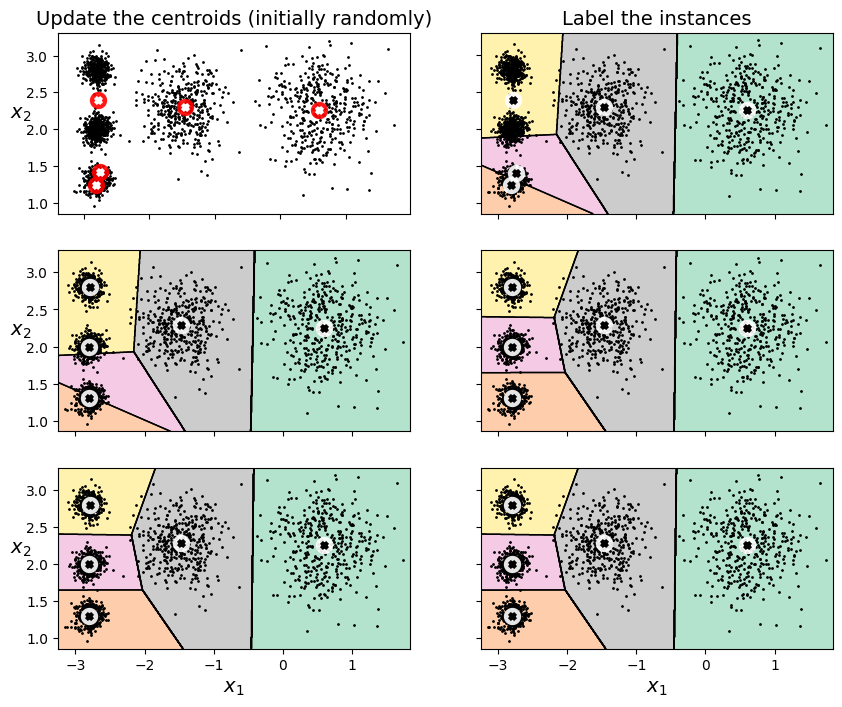

In [ ]:
plt.figure(figsize=(10, 8))

plt.subplot(321)
plot_data(X)
plot_centroids(kmeans_iter1.cluster_centers_, circle_color='r', cross_color='w')
plt.ylabel("$x_2$", fontsize=14, rotation=0)
plt.tick_params(labelbottom=False)
plt.title("Update the centroids (initially randomly)", fontsize=14)

plt.subplot(322)
plot_decision_boundaries(kmeans_iter1, X, show_xlabels=False, show_ylabels=False)
plt.title("Label the instances", fontsize=14)

plt.subplot(323)
plot_decision_boundaries(kmeans_iter1, X, show_centroids=False, show_xlabels=False)
plot_centroids(kmeans_iter2.cluster_centers_)

plt.subplot(324)
plot_decision_boundaries(kmeans_iter2, X, show_xlabels=False, show_ylabels=False)

plt.subplot(325)
plot_decision_boundaries(kmeans_iter2, X, show_centroids=False)
plot_centroids(kmeans_iter3.cluster_centers_)

plt.subplot(326)
plot_decision_boundaries(kmeans_iter3, X, show_ylabels=False)

#save_fig("kmeans_algorithm_plot")
plt.show()

- Podemos ver el algoritmo en acción en la Figura anterior, los centroides se inicializan aleatoriamente (arriba a la izquierda).
- Luego las instancias se etiquetan (arriba a la derecha).
- Luego los centroides se actualizan (centro a la izquierda).
- Seguido, las instancias se vuelven a etiquetar (centro a la derecha ), y así.

- **NOTA:** La complejidad computacional del algoritmo es generalmente lineal con respecto al número de instancias, el número de clústeres $k$ y el número de dimensiones.

- Sin embargo, esto solo es cierto cuando los datos tienen una estructura de agrupamiento. Si no es así, entonces, en el peor de los casos, la complejidad puede aumentar exponencialmente con el número de instancias.

### Variabilidad en K-Means

**Ejemplo:** la siguiente Figura muestra dos soluciones subóptimas con las que el algoritmo puede converger si no tiene suerte con el paso de inicialización aleatoria:

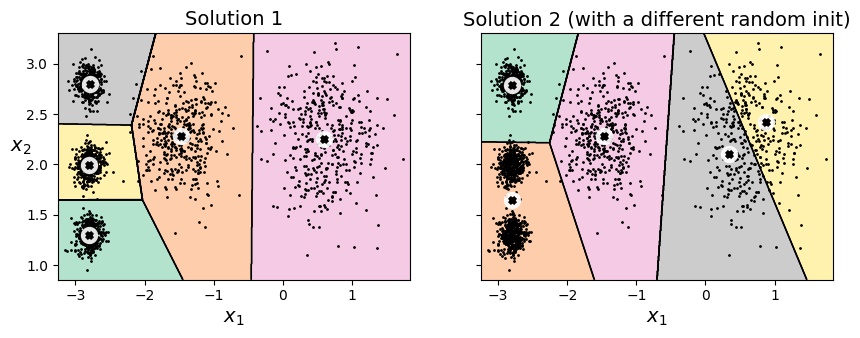

In [ ]:
def plot_clusterer_comparison(clusterer1, clusterer2, X, title1=None, title2=None):
    clusterer1.fit(X)
    clusterer2.fit(X)

    plt.figure(figsize=(10, 3.2))

    plt.subplot(121)
    plot_decision_boundaries(clusterer1, X)
    if title1:
        plt.title(title1, fontsize=14)

    plt.subplot(122)
    plot_decision_boundaries(clusterer2, X, show_ylabels=False)
    if title2:
        plt.title(title2, fontsize=14)

kmeans_rnd_init1 = KMeans(n_clusters=5, init="random", n_init=1,
                         random_state=110)
kmeans_rnd_init2 = KMeans(n_clusters=5, init=np.array([[-3,2.7],[-2.9,2.5],[-1,0.5],[-0.9,0.3],[0.5,0.5]]), n_init=1,
                          random_state=190)

plot_clusterer_comparison(kmeans_rnd_init1, kmeans_rnd_init2, X,
                          "Solution 1", "Solution 2 (with a different random init)")

#save_fig("kmeans_variability_plot")
plt.show()

### Métodos de inicialización de centroides

Si sabemos aproximadamente dónde deberían estar los centroides (por ejemplo, si ejecutó otro algoritmo de agrupación anteriormente), puede establecer el hiperparámetro *init* en una matriz NumPy que contiene la lista de centroides y establecer *n_init* en 1:

In [ ]:
good_init = np.array([[-3, 3], [-3, 2], [-3, 1], [-1, 2], [0, 2]])
kmeans    = KMeans(n_clusters=5, init=good_init, n_init=1, random_state=42)
kmeans.fit(X)

KMeans(init=array([[-3,  3],
       [-3,  2],
       [-3,  1],
       [-1,  2],
       [ 0,  2]]),
       n_clusters=5, n_init=1, random_state=42)

- Otra solución es **ejecutar el algoritmo varias veces con diferentes inicializaciones aleatorias y retonar la mejor solución**.

- Esto se controla mediante el hiperparámetro *n_init*: de forma predeterminada, es igual a 10, lo que significa que todo el algoritmo descrito anteriormente se ejecuta 10 veces cuando se llama al método *fit()*, y Scikit-Learn mantiene la mejor solución.

- Pero, **¿cómo sabe exactamente cuál solución es la mejor?**

- K-means utiliza una métrica de rendimiento llamada *inercia del modelo*: distancia cuadrática media entre cada instancia y su centroide más cercano.

In [ ]:
kmeans.inertia_

213.85700616373146

- El método *score()* devuelve la inercia negativa. ¿Por qué negativo? **porque el método *score()* de un predictor siempre debe respetar la regla, a mayor valor mejor**.

In [ ]:
kmeans.score(X)

-213.85700616373148

### Múltiples inicializaciones

- Un enfoque para resolver el problema de la variabilidad es **simplemente ejecutar el algoritmo K-Means varias veces con diferentes inicializaciones aleatorias y seleccionar la solución que minimice la inercia**.

- **Ejemplo:** tenemos las inercias de los dos modelos *"malos"* que se muestran en la figura anterior:

In [ ]:
kmeans_rnd_init1.inertia_

213.85458436211906

In [ ]:
kmeans_rnd_init2.inertia_

272.8609528813104

- Cuando configuramos el hiperparámetro *n_init*, Scikit-Learn ejecuta el algoritmo original *n_init* veces y selecciona la solución que minimiza la inercia. Por defecto, Scikit-Learn establece *n_init = 10*.

In [ ]:
kmeans_rnd_10_inits = KMeans(n_clusters=5, init="random", n_init=10,
                               random_state=11)
kmeans_rnd_10_inits.fit(X)

KMeans(init='random', n_clusters=5, n_init=10, random_state=11)

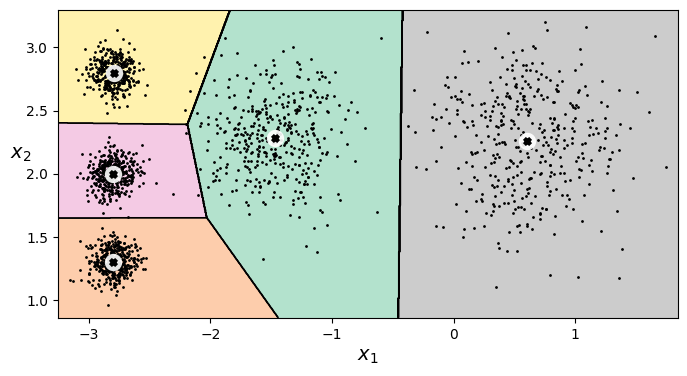

In [ ]:
plt.figure(figsize=(8, 4))
plot_decision_boundaries(kmeans_rnd_10_inits, X)
plt.show()

### K-Means++

- Para establecer la inicialización en K-Means ++, simplemente se configura *init="k-means ++"* (esto es realmente el valor predeterminado):

- K-means ++ genera centros lejanos entre si para abarcar mejor el espacio de búsqueda.

In [ ]:
KMeans()

KMeans()

### Accelerated K-Means

- Para usar la variante K-Means de **Elkan**, simplemente configure *algorithm = "elkan"*.

- Tenga en cuenta que no admite datos dispersos, por lo que, de forma predeterminada, Scikit-Learn usa "*elkan*" para datos densos y "*full*" (el algoritmo K-Means normal) para datos ralos.

- ElKan aprovecha la desigualdad triangular para estimar de forma eficiente las distancias entre puntos.

In [ ]:
%timeit -n 20 KMeans(algorithm="elkan",n_init='auto').fit(X)

13.7 ms ± 1.38 ms per loop (mean ± std. dev. of 7 runs, 20 loops each)


In [ ]:
%timeit -n 20 KMeans(n_init='auto').fit(X)

7.74 ms ± 1.3 ms per loop (mean ± std. dev. of 7 runs, 20 loops each)


### Mini-Batch K-Means

- Implementación de K-means por lotes.

- Actualiza los centros sobre subconjuntos aleatorios de puntos, favoreciendo el costo computacional.


In [ ]:
from sklearn.cluster import MiniBatchKMeans

minibatch_kmeans = MiniBatchKMeans(n_clusters=5, random_state=42,n_init='auto')
minibatch_kmeans.fit(X)

MiniBatchKMeans(n_clusters=5, random_state=42)

In [ ]:
minibatch_kmeans.inertia_

313.93439856837193

- Si el conjunto de datos no cabe en la memoría RAM, la opción más simple es usar la clase *memmap*.

- **Ejemplo:** Primero carguemos la base de datos de dígitos escritos a mano MNIST:

In [ ]:
import os
import tensorflow as tf
from tensorflow import keras

fashion_mnist = keras.datasets.fashion_mnist #cargar fashion mnist
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()
X_train = X_train.reshape(X_train.shape[0], -1)/255.
X_test  = X_test.reshape(X_test.shape[0], -1)/255.

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


- A continuación, escribámoslo en un *memmap*:

In [ ]:
from tempfile import mkdtemp
import os.path as path
filename = path.join(mkdtemp(), 'my_mnist.data')
X_mm     = np.memmap(filename, dtype='float32', mode='w+', shape=X_train.shape)
X_mm[:]  = X_train

# Flush changes to disk -> actualizar en disco
X_mm.flush()

del X_mm

- Ahora cargamos y entrenamos desde el memmap:

In [ ]:
X_mm = np.memmap(filename, dtype='float32', mode='r', shape=X_train.shape)
minibatch_kmeans = MiniBatchKMeans(n_clusters=10, batch_size=10, random_state=42,n_init='auto')
minibatch_kmeans.fit(X_mm)

MiniBatchKMeans(batch_size=10, n_clusters=10, random_state=42)

- Si nuestros datos son tan grandes que no puede usar *memmap*, las cosas se vuelven más complicadas.

- Comencemos escribiendo una función para cargar el próximo lote :

In [ ]:
def load_next_batch(batch_size):
    return X[np.random.choice(len(X), batch_size, replace=False)]

- Ahora podemos entrenar al modelo al alimentarlo un batch a la vez.

- También necesitamos implementar múltiples inicializaciones y mantener el modelo con la menor inercia:

In [ ]:
np.random.seed(42)

X = X_train

k            = 5
n_init       = 10
n_iterations = 100
batch_size   = 100
init_size    = 500  # more data for K-Means++ initialization
evaluate_on_last_n_iters = 10

best_kmeans = None

for init in range(n_init):
    minibatch_kmeans = MiniBatchKMeans(n_clusters=k, init_size=init_size,n_init='auto')
    X_init = load_next_batch(init_size)
    minibatch_kmeans.partial_fit(X_init)

    minibatch_kmeans.sum_inertia_ = 0
    for iteration in range(n_iterations):
        X_batch = load_next_batch(batch_size)
        minibatch_kmeans.partial_fit(X_batch)
        if iteration >= n_iterations - evaluate_on_last_n_iters:
            minibatch_kmeans.sum_inertia_ += minibatch_kmeans.inertia_

    if (best_kmeans is None or
        minibatch_kmeans.sum_inertia_ < best_kmeans.sum_inertia_):
        best_kmeans = minibatch_kmeans

best_kmeans.score(X)

-2357706.880524697

**Mini-batch K-Means es mucho más rápido que los K-Means normales**:

In [ ]:
%timeit KMeans(n_clusters=5,n_init='auto').fit(X)

6.95 s ± 2.79 s per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [ ]:
%timeit MiniBatchKMeans(n_clusters=5,n_init='auto').fit(X)

671 ms ± 233 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


- **¡Eso es mucho más rápido!** Sin embargo, su rendimiento es a menudo más bajo (mayor inercia), y se sigue degradando a medida que aumenta $k$.


# Cómo encontrar el número de grupos?

- **Ejemplo:** como podemos ver a continuación, establecer $k$ en 3 o 8 da como resultado modelos bastante malos:

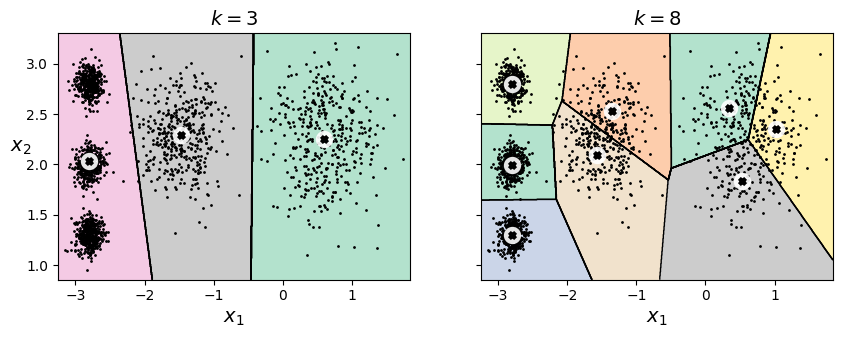

In [ ]:
kmeans_k3 = KMeans(n_clusters=3, random_state=42)
kmeans_k8 = KMeans(n_clusters=8, random_state=42)

X = X_ #gaussians

plot_clusterer_comparison(kmeans_k3, kmeans_k8, X, "$k=3$", "$k=8$")
#save_fig("bad_n_clusters_plot")
plt.show()

- **TIP:** Quizás estemos pensando que podríamos **elegir el modelo con la menor inercia**.

- **Respuesta:** Lamentablemente, no es tan simple. La inercia no es una buena medida de rendimiento cuando se trata de elegir $k$, ya que sigue disminuyendo a medida que aumentamos $k$. De hecho, cuantos más grupos haya, más cerca estará cada instancia de su centroide más cercano.

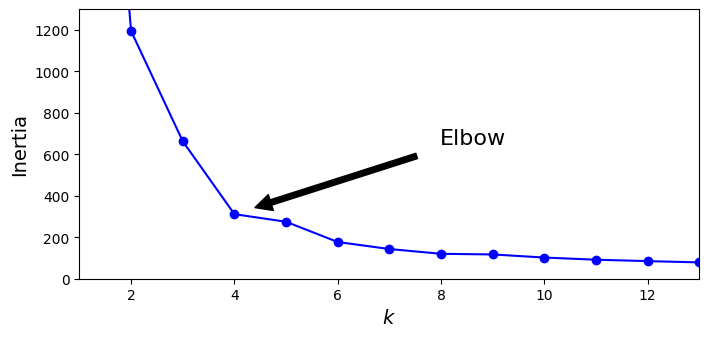

In [ ]:
kmeans_per_k = [KMeans(n_clusters=k, random_state=42,n_init='auto').fit(X)
                for k in range(1, 14)]
inertias     = [model.inertia_ for model in kmeans_per_k]

plt.figure(figsize=(8, 3.5))
plt.plot(range(1, 14), inertias, "bo-")
plt.xlabel("$k$", fontsize=14)
plt.ylabel("Inertia", fontsize=14)
plt.annotate('Elbow',
             xy=(4, inertias[3]),
             xytext=(0.55, 0.55),
             textcoords='figure fraction',
             fontsize=16,
             arrowprops=dict(facecolor='black', shrink=0.1)
            )
plt.axis([1, 13, 0, 1300])
#save_fig("inertia_vs_k_plot")
plt.show()

- Como podemos ver, la inercia cae muy rápidamente a medida que aumentamos $k$ hasta 4, pero luego disminuye mucho más lentamente a medida que seguimos aumentando $k$.
- Esta curva tiene aproximadamente la forma de un brazo, y hay un "*codo*" en $k = 4$, por lo que si no lo supiéramos mejor, sería una buena opción: cualquier valor más bajo sería dramático, mientras que cualquier valor más alto no ayudaría mucho.

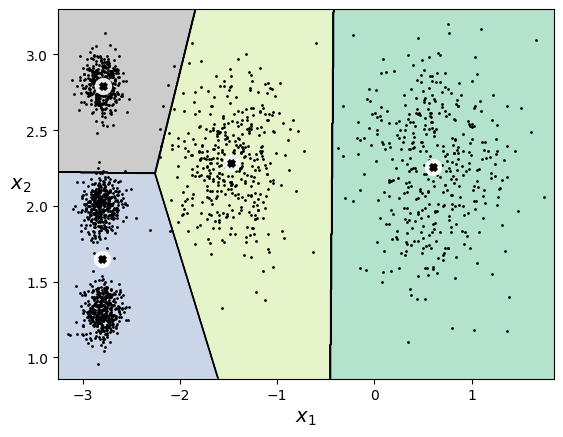

In [ ]:
plot_decision_boundaries(kmeans_per_k[4-1], X)
plt.show()

### Silueta

- Una altenativata a la inercia, es el *silhouette score*, como versión normalizada por grupo del concepto de inercia:


\begin{equation}
s_n = \frac{b_n - a_n}{\max(a_n, b_n)}
\end{equation}

\begin{equation}
S = \frac{1}{N} \sum_{n=1}^{N} s_n
\end{equation}


- $a_n:$ distancia promedio desde la muestra n a todos los puntos en el mismo cluster.

- $b_n:$ distancia mínima desde la muestra n a todos los puntos en el cluster más cercano.

- Puede usar la función *silhouette_score()* de Scikit-Learn, dándole todas las instancias en el conjunto de datos y las etiquetas que se les asignaron.


Tracemos la puntuación de la silueta en función de $k$:

In [ ]:
from sklearn.metrics import silhouette_score
silhouette_score(X, kmeans.labels_)

np.float64(0.7000294635075308)

Comparemos los puntajes de silueta para diferentes números de grupos:

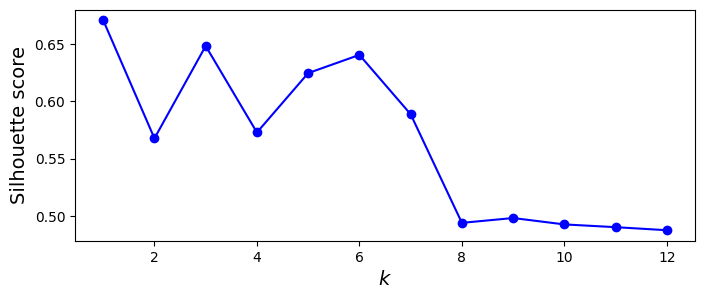

In [ ]:
silhouette_scores = [silhouette_score(X, model.labels_)
                     for model in kmeans_per_k[1:]]

plt.figure(figsize=(8, 3))
plt.plot(range(1, 13), silhouette_scores, "bo-")
plt.xlabel("$k$", fontsize=14)
plt.ylabel("Silhouette score", fontsize=14)
#plt.axis([1.8, 8.5, 0.55, 0.7])
#save_fig("silhouette_score_vs_k_plot")
plt.show()

- Como podemos ver, aunque **confirma que $k = 4$ es una muy buena opción**.

Adicionalmente, obtenemos una visualización aún más informativa cuando trazamos el *silhouette score* de cada instancia, ordenado por el grupo al que están asignados y por el valor del coeficiente (**diagrama de silueta**):

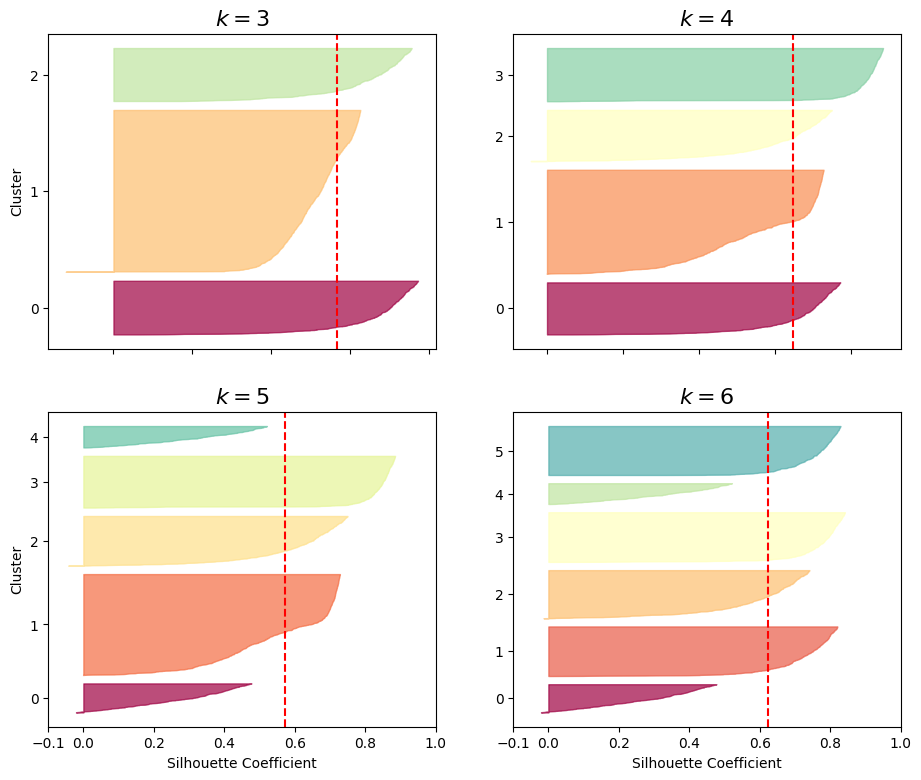

In [ ]:
import matplotlib as mpl
from sklearn.metrics import silhouette_samples
from matplotlib.ticker import FixedLocator, FixedFormatter

plt.figure(figsize=(11, 9))

for k in (3, 4, 5, 6):
    plt.subplot(2, 2, k - 2)

    y_pred                  = kmeans_per_k[k - 1].labels_
    silhouette_coefficients = silhouette_samples(X, y_pred)

    padding = len(X) // 30
    pos     = padding
    ticks   = []
    for i in range(k):
        coeffs = silhouette_coefficients[y_pred == i]
        coeffs.sort()

        color = mpl.cm.Spectral(i / k)
        plt.fill_betweenx(np.arange(pos, pos + len(coeffs)), 0, coeffs,
                          facecolor=color, edgecolor=color, alpha=0.7)
        ticks.append(pos + len(coeffs) // 2)
        pos += len(coeffs) + padding

    plt.gca().yaxis.set_major_locator(FixedLocator(ticks))
    plt.gca().yaxis.set_major_formatter(FixedFormatter(range(k)))
    if k in (3, 5):
        plt.ylabel("Cluster")

    if k in (5, 6):
        plt.gca().set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])
        plt.xlabel("Silhouette Coefficient")
    else:
        plt.tick_params(labelbottom=False)

    plt.axvline(x=silhouette_scores[k - 2], color="red", linestyle="--")
    plt.title("$k={}$".format(k), fontsize=16)

#save_fig("silhouette_analysis_plot")
plt.show()

- Las líneas discontinuas verticales representan el *silhouette score* por grupo.
- Cuando la mayoría de las instancias en un grupo tienen un coeficiente más bajo que este puntaje (es decir, si muchas de las instancias se detienen cerca de la línea punteada, terminando a la izquierda de la misma), entonces **el grupo es bastante malo, sus instancias están demasiado cerca de otros grupos**.


### Consideraciones sobre K-Means

**Ejemplo:** la Figura a continuación muestra cómo KMeans agrupa un conjunto de datos que contiene tres grupos elipsoidales de diferentes dimensiones, densidades y orientaciones:

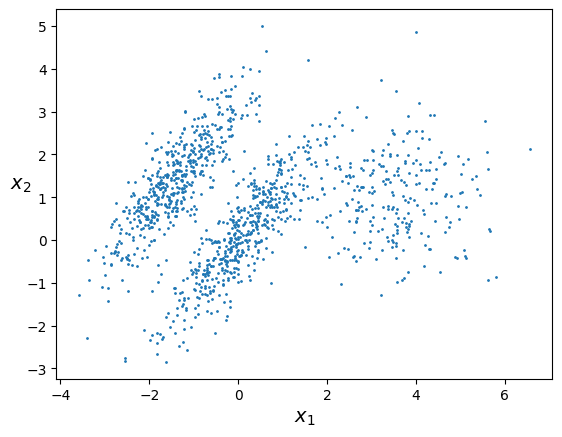

In [ ]:
X1, y1 = make_blobs(n_samples=1000, centers=((4, -4), (0, 0)), random_state=42)
X1     = X1.dot(np.array([[0.374, 0.95], [0.732, 0.598]]))
X2, y2 = make_blobs(n_samples=250, centers=1, random_state=42)
X2     = X2 + [6, -8]
X      = np.r_[X1, X2]
y      = np.r_[y1, y2]

plot_clusters(X)

In [ ]:
kmeans_good = KMeans(n_clusters=3, init=np.array([[-1.5, 2.5], [0.5, 0], [4, 0]]), n_init=1, random_state=42)
kmeans_bad  = KMeans(n_clusters=3, random_state=42)
kmeans_good.fit(X)
kmeans_bad.fit(X)

KMeans(n_clusters=3, random_state=42)

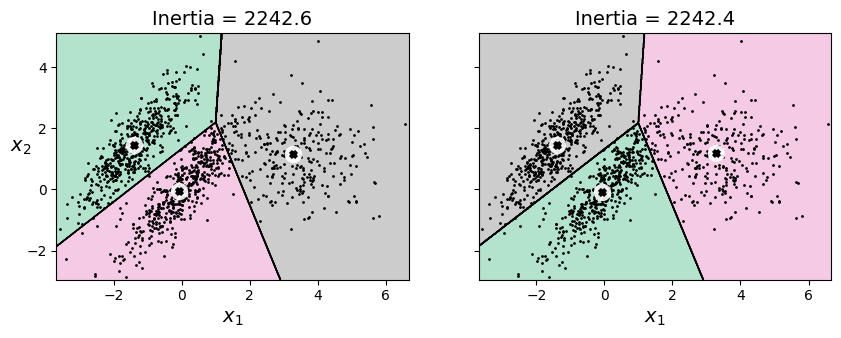

In [ ]:
plt.figure(figsize=(10, 3.2))

plt.subplot(121)
plot_decision_boundaries(kmeans_good, X)
plt.title("Inertia = {:.1f}".format(kmeans_good.inertia_), fontsize=14)

plt.subplot(122)
plot_decision_boundaries(kmeans_bad, X, show_ylabels=False)
plt.title("Inertia = {:.1f}".format(kmeans_bad.inertia_), fontsize=14)

#save_fig("bad_kmeans_plot")
plt.show()

Como podemos ver, **ninguna de estas soluciones es buena**.

- La solución a la izquierda es mejor, pero aún corta el $25\%$ del grupo intermedio y lo asigna al grupo a la derecha.
- La solución a la derecha es simplemente terrible, a pesar de que su inercia es menor.

Entonces, dependiendo de los datos, los diferentes algoritmos de agrupación pueden funcionar mejor. Por ejemplo, en estos tipos de grupos elípticos, los **modelos de mezcla gaussiana** funcionan muy bien.

**TIP:** Es importante **escalar las características de entrada antes de ejecutar K-Means**, de lo contrario, los grupos pueden estar muy extendidos y K-Means funcionará mal. Escalar las características no garantiza que todos los clústeres sean agradables y esféricos, pero generalmente mejora las cosas.

## DBSCAN

- Density-Based Spatial Clustering of Applications with Noise (DBSCAN) es un algoritmo de clustering que considera la densidad de puntos en una región.

- Puede ser útil para estructuras no lineales y para la detección de atípicos.

- Su funcionamiento se centra en la estimación de vecindarios:


\begin{equation}
N_{\varepsilon}(p) = \{q \in D \mid \text{dist}(p, q) \leq \varepsilon\}
\end{equation}

- Y tiene en cuenta la restricción:

\begin{equation}
|N_{\varepsilon}(p)| \geq \text{minPts}
\end{equation}

- Un punto es considerado alcanzable (core-point), si:

\begin{equation}
q \in N_{\varepsilon}(p) \quad \text{and} \quad |N_{\varepsilon}(p)| \geq \text{minPts}
\end{equation}

In [ ]:
from sklearn.datasets import make_moons
X, y = make_moons(n_samples=300, noise=0.05, random_state=42)

In [ ]:
from sklearn.cluster import DBSCAN
dbscan = DBSCAN(eps=0.05, min_samples=5)
dbscan.fit(X)

DBSCAN(eps=0.05)

Las etiquetas de todas las instancias ahora están disponibles en la variable *labels_ instance*:

In [ ]:
dbscan.labels_[:10]

array([-1, -1, -1, -1, -1, -1,  0, -1,  5, -1])

- Tenga en cuenta que algunas instancias tienen un índice de clúster igual a **-1**: esto significa que **el algoritmo las considera anomalías**.

- Los índices de las instancias centrales están disponibles en la variable de instancia *core_sample_indices_*, y las propias instancias centrales están disponibles en la variable *components_ instance*:

In [ ]:
len(dbscan.core_sample_indices_)

13

In [ ]:
dbscan.core_sample_indices_

array([  6,  17,  34,  90, 128, 165, 179, 227, 234, 246, 247, 249, 276])

In [ ]:
dbscan.components_[:3]

array([[ 0.4119847 , -0.28596972],
       [ 0.72038373, -0.41616684],
       [ 0.76244287, -0.39694127]])

In [ ]:
import numpy as np
np.unique(dbscan.labels_)

array([-1,  0,  1,  2,  3,  4,  5,  6])

In [ ]:
dbscan2 = DBSCAN(eps=0.2)
dbscan2.fit(X)

DBSCAN(eps=0.2)

In [ ]:
def plot_dbscan(dbscan, X, size, show_xlabels=True, show_ylabels=True):
    core_mask = np.zeros_like(dbscan.labels_, dtype=bool)
    core_mask[dbscan.core_sample_indices_] = True
    anomalies_mask = dbscan.labels_ == -1
    non_core_mask = ~(core_mask | anomalies_mask)

    cores = dbscan.components_
    anomalies = X[anomalies_mask]
    non_cores = X[non_core_mask]

    plt.scatter(cores[:, 0], cores[:, 1],
                c=dbscan.labels_[core_mask], marker='o', s=size, cmap="Paired")
    plt.scatter(cores[:, 0], cores[:, 1], marker='*', s=20, c=dbscan.labels_[core_mask])
    plt.scatter(anomalies[:, 0], anomalies[:, 1],
                c="r", marker="x", s=100)
    plt.scatter(non_cores[:, 0], non_cores[:, 1], c=dbscan.labels_[non_core_mask], marker=".")
    if show_xlabels:
        plt.xlabel("$x_1$", fontsize=14)
    else:
        plt.tick_params(labelbottom=False)
    if show_ylabels:
        plt.ylabel("$x_2$", fontsize=14, rotation=0)
    else:
        plt.tick_params(labelleft=False)
    plt.title("eps={:.2f}, min_samples={}".format(dbscan.eps, dbscan.min_samples), fontsize=14)

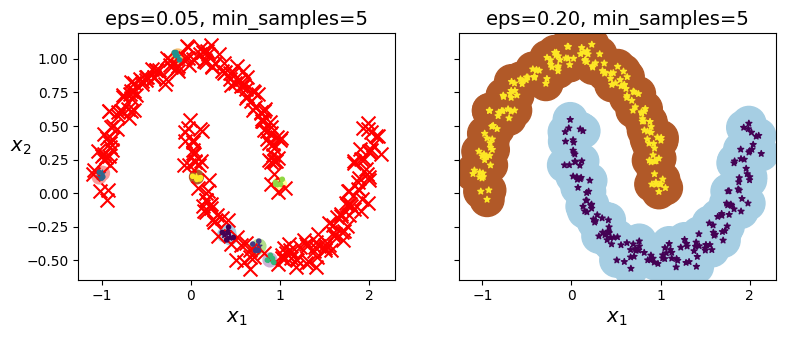

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(9, 3.2))

plt.subplot(121)
plot_dbscan(dbscan, X, size=100)

plt.subplot(122)
plot_dbscan(dbscan2, X, size=600, show_ylabels=False)

#save_fig("dbscan_plot")
plt.show()


- Como podemos ver, el algoritmo identificó bastantes anomalías, además de 7 grupos diferentes.

Afortunadamente, si **ampliamos el vecindario de cada instancia** al aumentar $\epsilon$ a 0.2, obtenemos el agrupamiento a la derecha, que se ve perfecto.

La clase **DBSCAN** no tiene un método *predict_()*, aunque tiene un método *fit_predict_()*. En otras palabras, no puede predecir a qué clúster pertenece una nueva instancia. La razón de esta decisión es que varios algoritmos de clasificación podrían tener sentido aquí, y es bastante fácil entrenar uno, por ejemplo, un clasificador K-NN:

In [ ]:
dbscan = dbscan2

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=50)
knn.fit(dbscan.components_, dbscan.labels_[dbscan.core_sample_indices_])

KNeighborsClassifier(n_neighbors=50)

- Ahora, dadas algunas instancias nuevas, **podemos predecir a qué grupo probablemente pertenecerán**, e incluso **estimar una probabilidad para cada grupo**.
- Tengamos en cuenta que solo los entrenamos en las instancias centrales, pero también podríamos haber optado por usar **todas las instancias**, o **todas menos las anomalías**: esta elección depende de la tarea final.

In [ ]:
X_new = np.array([[-0.5, 0], [0, 0.5], [1, -0.1], [2, 1]])
knn.predict(X_new)

array([1, 0, 0, 0])

In [ ]:
knn.predict_proba(X_new)

array([[0.4 , 0.6 ],
       [0.52, 0.48],
       [0.66, 0.34],
       [0.76, 0.24]])

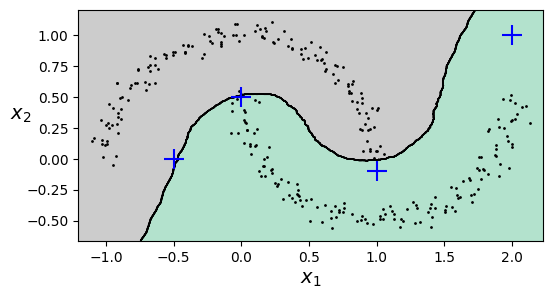

In [ ]:
plt.figure(figsize=(6, 3))
plot_decision_boundaries(knn, X, show_centroids=False)
plt.scatter(X_new[:, 0], X_new[:, 1], c="b", marker="+", s=200, zorder=10)
#save_fig("cluster_classification_plot")
plt.show()

El límite de decisión se representa en la Figura anterior:
- Las cruces representan las 4 instancias en *X_new*.
- Tengamos en cuenta que, dado que no hay ninguna anomalía en el conjunto de entrenamiento del KNN, **el clasificador siempre elige un grupo, incluso cuando ese grupo está muy lejos**.

Sin embargo, es bastante sencillo introducir una *distancia máxima*, en cuyo caso **las dos instancias que están lejos de ambos grupos se clasifican como anomalías**. Para hacer esto, podemos usar el método de los *kneighbors()* del **KNeighsClassifier**: dado un conjunto de instancias, devuelve las distancias y los índices de los $k$ vecinos más cercanos en el conjunto de entrenamiento (dos matrices, cada una con $k$ columnas):

In [ ]:
y_dist, y_pred_idx = knn.kneighbors(X_new, n_neighbors=1)
y_pred = dbscan.labels_[dbscan.core_sample_indices_][y_pred_idx]
y_pred[y_dist > 0.2] = -1
y_pred.ravel()

array([-1,  0,  1, -1])

### Spectral clustering

- Se basa en la similitud entre puntos (Gaussian kernel)

\begin{equation}
w_{nm} = \exp\left(-\frac{\|x_n - x_m\|^2}{2\sigma^2}\right)
\end{equation}

- Tiene en cuenta el grado de la matriz de similitud para ser robusta a datos atípicos:

\begin{equation}
d_{nn} = \sum_{m} w_{nm}
\end{equation}

- Posteriormente, se encuenta la matríz Laplaciano:

\begin{equation}
L = D - W
\end{equation}

- Y se normaliza:

\begin{equation}
L_{sym} = D^{-\frac{1}{2}} L D^{-\frac{1}{2}} = I - D^{-\frac{1}{2}} W D^{-\frac{1}{2}}
\end{equation}

- Otra alternativa de normalización:

\begin{equation}
L_{rw} = D^{-1} L = I - D^{-1} W
\end{equation}

- Se descompone en valores y vectores propios:

\begin{equation}
L \mathbf{u} = \lambda \mathbf{u}
\end{equation}

- Finalmente se aplica un algoritmo tradicional de clustering, e.g., Kmeans, sobre los vectores propios escogidos.

In [ ]:
from sklearn.cluster import SpectralClustering
sc1 = SpectralClustering(n_clusters=2, gamma=100, random_state=42)
sc1.fit(X)

SpectralClustering(gamma=100, n_clusters=2, random_state=42)

In [ ]:
sc2 = SpectralClustering(n_clusters=2, gamma=1, random_state=42)
sc2.fit(X)

SpectralClustering(gamma=1, n_clusters=2, random_state=42)

In [ ]:
np.percentile(sc1.affinity_matrix_, 95) #puntos con similitud alta

np.float64(0.037950332908433894)

In [ ]:
def plot_spectral_clustering(sc, X, size, alpha, show_xlabels=True, show_ylabels=True):
    plt.scatter(X[:, 0], X[:, 1], marker='o', s=size, c='gray', cmap="Paired", alpha=alpha)
    plt.scatter(X[:, 0], X[:, 1], marker='o', s=30, c='w')
    plt.scatter(X[:, 0], X[:, 1], marker='.', s=10, c=sc.labels_, cmap="Paired")

    if show_xlabels:
        plt.xlabel("$x_1$", fontsize=14)
    else:
        plt.tick_params(labelbottom=False)
    if show_ylabels:
        plt.ylabel("$x_2$", fontsize=14, rotation=0)
    else:
        plt.tick_params(labelleft=False)
    plt.title("RBF gamma={}".format(sc.gamma), fontsize=14)

/tmp/ipython-input-3890908347.py:2: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X[:, 0], X[:, 1], marker='o', s=size, c='gray', cmap="Paired", alpha=alpha)


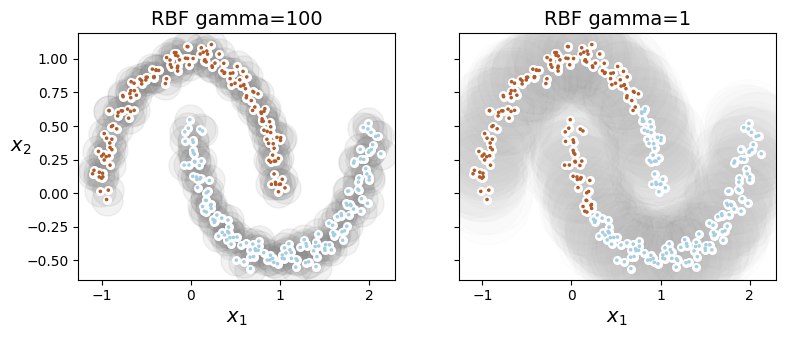

In [ ]:
plt.figure(figsize=(9, 3.2))

plt.subplot(121)
plot_spectral_clustering(sc1, X, size=500, alpha=0.1)

plt.subplot(122)
plot_spectral_clustering(sc2, X, size=4000, alpha=0.01, show_ylabels=False)

plt.show()

### Gráfico tipo grafo

- Grafiquemos un grafo sobre los datos a partir de la similitud calculada

In [ ]:
!pip install networkx matplotlib

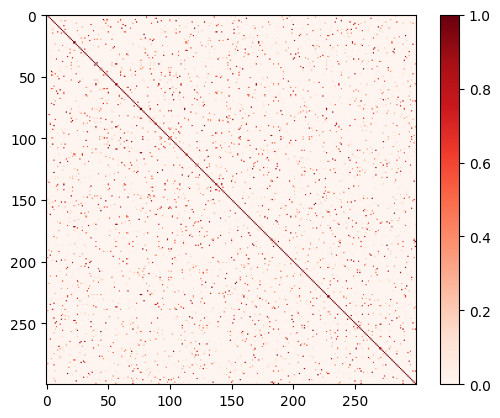

In [ ]:
import networkx as nx
from scipy.spatial.distance import cdist, squareform
# Gaussian similarity

def gaussK(X,gamma=1):
  D = cdist(X,X)
  return np.exp(-gamma*D**2)

similarity_matrix = gaussK(X,gamma=100)
plt.imshow(similarity_matrix,cmap='Reds')
plt.colorbar()
plt.show()

In [ ]:
# Create a graph from the similarity matrix using NetworkX

th_ = np.percentile(similarity_matrix, 90)

G = nx.Graph()

# Add nodes
for i in range(similarity_matrix.shape[0]):
    G.add_node(i)

# Add edges with weights
for i in range(similarity_matrix.shape[0]):
    for j in range(i + 1, similarity_matrix.shape[0]):
        if similarity_matrix[i, j] > th_:  # Optional: threshold to filter weak connections
            G.add_edge(i, j, weight=similarity_matrix[i, j])



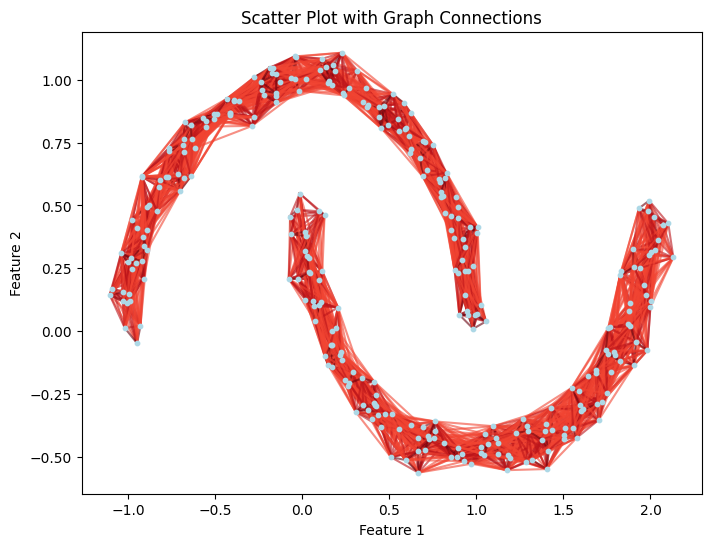

In [ ]:
import matplotlib.cm as cm
plt.figure(figsize=(8, 6))

vq = np.percentile(similarity_matrix, [50,75,80,90,95,99])
colormap = plt.get_cmap('Reds',len(vq))
colors = colormap(np.linspace(0, 1, len(vq)))


# Scatter plot of the data points
plt.scatter(X[:, 0], X[:, 1], c='lightblue', s=10, zorder=2)
# Plot the graph connections
for (i, j) in G.edges():
    plt.plot([X[i, 0], X[j, 0]], [X[i, 1], X[j, 1]],
             c=colors[np.argmin(cdist(similarity_matrix[i,j].reshape(-1,1),vq.reshape(-1,1)))], alpha=0.6, zorder=1)

plt.title('Scatter Plot with Graph Connections')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')

sm = plt.cm.ScalarMappable(cmap=colormap, norm=plt.Normalize(0, 1))
#plt.colorbar(sm, label='Vector Value')
plt.show()

# Ejercicios

Para los siguientes puntos, utilizar la librería [RAPIDS](https://rapids.ai/) a la hora de implementar los algoritmos estudiados, en caso de estar disponibles.

- Realice una comparación de los métodos de clustering vistos, para generar una segmentación de imagen a color, incluyendo la información de ubicación de cada pixel (ver Cuaderno guía [tanjiro](https://github.com/amalvarezme/AprendizajeMaquina/blob/main/4_Clasificacion_Clustering_DR/tanjiro.ipynb)). Varie la cantidad de grupos (niveles o clases de segmentación) $k\in\{3,5,7,9\}$ y presente los scores de inercia y silueta conseguidos.

- Repita el punto anterior realizando una proyección 2D de los datos con PCA y UMAP (ver guía [reducción de dimensión](https://github.com/amalvarezme/AprendizajeMaquina/blob/main/4_Clasificacion_Clustering_DR/8_ReduccionDimension.ipynb))
 antes de generar las segmentaciones.

--2025-10-26 23:20:06--  https://docs.google.com/uc?export=download&confirm=&id=1KENM6BW5UjRoSjnWmuBP_MS_NrC0cefP
Resolving docs.google.com (docs.google.com)... 74.125.199.138, 74.125.199.102, 74.125.199.139, ...
Connecting to docs.google.com (docs.google.com)|74.125.199.138|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1KENM6BW5UjRoSjnWmuBP_MS_NrC0cefP&export=download [following]
--2025-10-26 23:20:07--  https://drive.usercontent.google.com/download?id=1KENM6BW5UjRoSjnWmuBP_MS_NrC0cefP&export=download
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 142.250.107.132, 2607:f8b0:400e:c0d::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|142.250.107.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 6476 (6.3K) [image/jpeg]
Saving to: ‘tanjiro.jpeg’

tanjiro.jpeg        100%[===================>]   6.32K  --.-KB/s    in 0s    

(125, 125, 3)

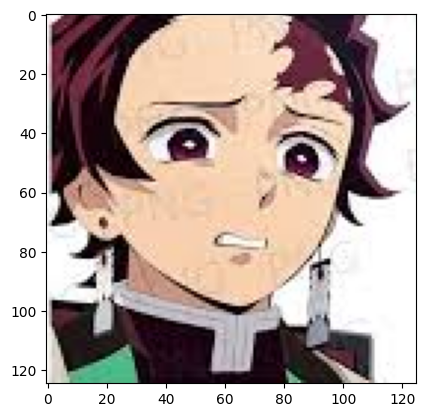

In [ ]:
#https://drive.google.com/file/d/1KENM6BW5UjRoSjnWmuBP_MS_NrC0cefP/view?usp=sharing

FILEID = "1KENM6BW5UjRoSjnWmuBP_MS_NrC0cefP"
!wget --load-cookies /tmp/cookies.txt "https://docs.google.com/uc?export=download&confirm=$(wget --quiet --save-cookies /tmp/cookies.txt --keep-session-cookies --no-check-certificate 'https://docs.google.com/uc?export=download&id='$FILEID -O- | sed -rn 's/.*confirm=([0-9A-Za-z_]+).*/\1\n/p')&id="$FILEID -O tanjiro.jpeg && rm -rf /tmp/cookies.txt


import os
import matplotlib.pyplot as plt
from matplotlib.image import imread
import numpy as np
image = imread(os.path.join("tanjiro.jpeg"))
image = image[50:175,50:175,:]
plt.imshow(image)
image.shape

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


[2025-10-26 23:30:59.056] [CUML] [info] Batch size limited by the chosen integer type (4 bytes). 50016 -> 42419. Using the larger integer type might result in better performance


,Metodo,k,Inercia,Silhouette,Clusters,Tiempo_s,PNG
12,DBSCAN (cuML),NaN,NaN,NaN,1,0.482075,seg_all_methods/dbscan.png
0,KMeans (cuML),3.0,6836.009277,0.349297,3,7.048859,seg_all_methods/kmeans_k3.png
1,KMeans (cuML),5.0,3785.875488,0.430467,5,0.625701,seg_all_methods/kmeans_k5.png
2,KMeans (cuML),7.0,2389.529053,0.444699,7,0.565414,seg_all_methods/kmeans_k7.png
3,KMeans (cuML),9.0,1841.706787,0.402059,9,0.636931,seg_all_methods/kmeans_k9.png
4,MiniBatchKMeans (CPU),3.0,6896.806152,0.340802,3,0.516671,seg_all_methods/minibatch_k3.png
5,MiniBatchKMeans (CPU),5.0,3783.883789,0.380359,5,0.670556,seg_all_methods/minibatch_k5.png
6,MiniBatchKMeans (CPU),7.0,2422.289307,0.443481,7,0.473648,seg_all_methods/minibatch_k7.png
7,MiniBatchKMeans (CPU),9.0,1971.081421,0.401205,9,0.457733,seg_all_methods/minibatch_k9.png
8,Spectral (CPU),3.0,NaN,0.130305,3,217.337112,seg_all_methods/spectral_k3.png



Imágenes guardadas en: /content/seg_all_methods


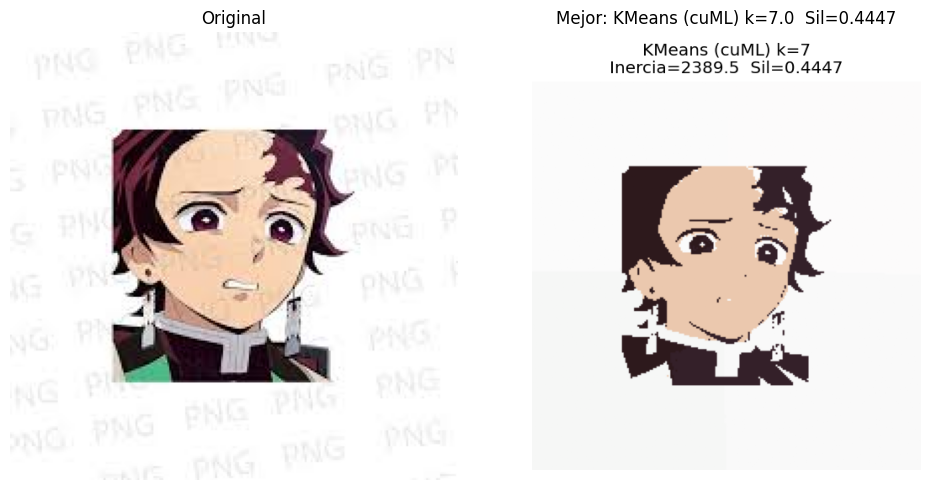

In [ ]:


# ============================================================
# 0) Imports y detección RAPIDS (GPU) + CPU fallback
# ============================================================
import os, time, numpy as np, pandas as pd, matplotlib.pyplot as plt

USE_GPU = True
try:
    import cupy as cp, cudf
    from cuml.cluster import KMeans as cuKMeans
    from cuml.cluster import DBSCAN as cuDBSCAN
    try:
        from cuml.metrics.cluster import silhouette_score as cu_silhouette
        HAS_GPU_SIL = True
    except Exception:
        HAS_GPU_SIL = False
except Exception as e:
    print(">> No se encontró RAPIDS/CuPy. Se usará CPU (scikit-learn).", e)
    USE_GPU, HAS_GPU_SIL = False, False

from skimage.io import imread
from skimage.color import rgb2lab, lab2rgb
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import silhouette_score as sk_silhouette

from sklearn.cluster import KMeans as skKMeans
from sklearn.cluster import MiniBatchKMeans as skMBKMeans
from sklearn.cluster import DBSCAN as skDBSCAN
from sklearn.cluster import SpectralClustering as skSpectral

# ============================================================
# 1) Utilidades de features, métricas, reconstrucción y helpers
# ============================================================
def to_lab(img_rgb_float):
    return rgb2lab(img_rgb_float)  # float64

def build_features(image_rgb, lambda_xy=0.7, use_lab=True):
    """X = [L,a,b, λx, λy] o [R,G,B, λx, λy] + (H,W)."""
    img = image_rgb.astype(np.float32)
    if img.max() > 1.0: img = img/255.0
    H, W, _ = img.shape

    if use_lab:
        lab = to_lab(img).astype(np.float32)
        color = lab.reshape(-1, 3)
    else:
        color = img.reshape(-1, 3)

    xs, ys = np.meshgrid(np.arange(W, dtype=np.float32),
                         np.arange(H, dtype=np.float32))
    coords = np.c_[lambda_xy*xs.ravel(), lambda_xy*ys.ravel()].astype(np.float32)
    X = np.c_[color, coords]
    return X, (H, W), img

def scale_features(X):
    scaler = MinMaxScaler()
    return scaler.fit_transform(X), scaler

def gpu_arr(X):
    return cp.asarray(X) if USE_GPU else X

def silhouette_any(Xs, labels, sample_size=None, random_state=42):
    uniq = np.unique(labels)
    if len(uniq) < 2: return np.nan
    if sample_size is not None and sample_size < len(labels):
        rng = np.random.default_rng(random_state)
        idx = rng.choice(len(labels), size=sample_size, replace=False)
        Xs_, y_ = Xs[idx], labels[idx]
    else:
        Xs_, y_ = Xs, labels
    if USE_GPU and HAS_GPU_SIL:
        try:
            return float(cu_silhouette(cp.asarray(Xs_), cp.asarray(y_)))
        except Exception:
            pass
    return float(sk_silhouette(Xs_, y_))

def seg_from_labels(labels, H, W, image_rgb, use_lab=True):
    """Color = promedio por clúster (en L*a*b* si use_lab=True)."""
    img = image_rgb.astype(np.float32)
    if img.max() > 1.0: img = img/255.0
    base = to_lab(img).astype(np.float32) if use_lab else img
    flat = base.reshape(-1,3)

    K = int(labels.max()) + 1
    cents = []
    for k in range(K):
        m = (labels == k)
        cents.append(flat[m].mean(axis=0) if m.any() else flat.mean(axis=0))
    cents = np.vstack(cents).astype(np.float32)

    seg_flat = cents[labels]
    seg_lab = seg_flat.reshape(H, W, 3)
    seg_rgb = lab2rgb(seg_lab) if use_lab else seg_lab
    return np.clip(seg_rgb, 0, 1)

def save_seg(fig_img, title, out_path):
    plt.figure(figsize=(5,5))
    plt.imshow(fig_img)
    plt.title(title)
    plt.axis('off')
    plt.savefig(out_path, bbox_inches="tight", dpi=120)
    plt.close()

# ============================================================
# 2) Config experimento
# ============================================================
IMAGE_PATH = "tanjiro.jpeg"   # <-- ajusta a tu path
OUT_DIR = "seg_all_methods"
os.makedirs(OUT_DIR, exist_ok=True)

KS = [3,5,7,9]
LAMBDA_XY = 0.7
USE_LAB = True
SIL_SAMPLE = None   # e.g., 10000 para acelerar en imágenes grandes
RANDOM_STATE = 42

# DBSCAN (no depende de k; ajusta según la imagen)
DBSCAN_EPS = 0.35
DBSCAN_MIN_SAMPLES = 50

# SpectralClustering (CPU): puede ser costoso en imágenes grandes
SPECTRAL_N_NEIGHBORS = 10   # afinidad 'nearest_neighbors'
SPECTRAL_ASSIGN_LABELS = "kmeans"  # interno

# ============================================================
# 3) Carga imagen y features
# ============================================================
image = imread(IMAGE_PATH)
X, (H,W), image_f = build_features(image, lambda_xy=LAMBDA_XY, use_lab=USE_LAB)
Xs, scaler = scale_features(X)

results = []

# ============================================================
# 4) KMEANS (GPU si hay, sino CPU)
# ============================================================
for k in KS:
    t0 = time.time()
    if USE_GPU:
        model = cuKMeans(n_clusters=k, n_init='auto', random_state=RANDOM_STATE)
        labels = model.fit_predict(gpu_arr(Xs))
        labels = cp.asnumpy(labels)
        inertia = float(model.inertia_)
        metodo = "KMeans (cuML)"
    else:
        model = skKMeans(n_clusters=k, n_init='auto', random_state=RANDOM_STATE)
        labels = model.fit_predict(Xs)
        inertia = float(model.inertia_)
        metodo = "KMeans (CPU)"
    sil = silhouette_any(Xs, labels, sample_size=SIL_SAMPLE, random_state=RANDOM_STATE)
    seg = seg_from_labels(labels, H, W, image, use_lab=USE_LAB)
    out_png = os.path.join(OUT_DIR, f"kmeans_k{k}.png")
    save_seg(seg, f"{metodo} k={k}\nInercia={inertia:.1f}  Sil={sil:.4f}", out_png)
    results.append(dict(Metodo=metodo, k=k, Inercia=inertia, Silhouette=sil,
                        Clusters=(labels.max()+1), Tiempo_s=time.time()-t0, PNG=out_png))

# ============================================================
# 5) MINIBATCH KMEANS (CPU)
# ============================================================
for k in KS:
    t0 = time.time()
    mbk = skMBKMeans(n_clusters=k, random_state=RANDOM_STATE, batch_size=2048)
    labels = mbk.fit_predict(Xs)
    inertia = float(mbk.inertia_)
    sil = silhouette_any(Xs, labels, sample_size=SIL_SAMPLE, random_state=RANDOM_STATE)
    seg = seg_from_labels(labels, H, W, image, use_lab=USE_LAB)
    out_png = os.path.join(OUT_DIR, f"minibatch_k{k}.png")
    save_seg(seg, f"MiniBatchKMeans (CPU) k={k}\nInercia={inertia:.1f}  Sil={sil:.4f}", out_png)
    results.append(dict(Metodo="MiniBatchKMeans (CPU)", k=k, Inercia=inertia, Silhouette=sil,
                        Clusters=(labels.max()+1), Tiempo_s=time.time()-t0, PNG=out_png))

# ============================================================
# 6) SPECTRAL CLUSTERING (CPU)
#     NOTA: costoso. Si tu imagen es grande, considera recortar o muestrear.
# ============================================================
for k in KS:
    t0 = time.time()
    sp = skSpectral(n_clusters=k,
                    affinity='nearest_neighbors',
                    n_neighbors=SPECTRAL_N_NEIGHBORS,
                    assign_labels=SPECTRAL_ASSIGN_LABELS,
                    random_state=RANDOM_STATE)
    labels = sp.fit_predict(Xs)
    inertia = np.nan  # no define inercia
    sil = silhouette_any(Xs, labels, sample_size=SIL_SAMPLE, random_state=RANDOM_STATE)
    seg = seg_from_labels(labels, H, W, image, use_lab=USE_LAB)
    out_png = os.path.join(OUT_DIR, f"spectral_k{k}.png")
    save_seg(seg, f"Spectral (CPU) k={k}\nSil={sil:.4f}", out_png)
    results.append(dict(Metodo="Spectral (CPU)", k=k, Inercia=inertia, Silhouette=sil,
                        Clusters=(labels.max()+1), Tiempo_s=time.time()-t0, PNG=out_png))

# ============================================================
# 7) DBSCAN (GPU si hay, sino CPU) — sin k
# ============================================================
t0 = time.time()
if USE_GPU:
    db = cuDBSCAN(eps=DBSCAN_EPS, min_samples=DBSCAN_MIN_SAMPLES)
    labels = db.fit_predict(gpu_arr(Xs))
    labels = cp.asnumpy(labels)
    metodo = "DBSCAN (cuML)"
else:
    db = skDBSCAN(eps=DBSCAN_EPS, min_samples=DBSCAN_MIN_SAMPLES, n_jobs=-1)
    labels = db.fit_predict(Xs)
    metodo = "DBSCAN (CPU)"

valid = labels[labels!=-1]
n_clust = len(np.unique(valid)) if valid.size>0 else 0
sil = silhouette_any(Xs[labels!=-1], labels[labels!=-1], sample_size=SIL_SAMPLE) if n_clust>=2 else np.nan
inertia = np.nan  # no aplica

# Para visualizar, mapea -1 (ruido) a clúster 0 para colorear algo (opcional)
vis_labels = labels.copy()
if (vis_labels==-1).any():
    nonneg = vis_labels[vis_labels!=-1]
    shift = nonneg.min() if nonneg.size>0 else 0
    vis_labels[vis_labels==-1] = shift  # junta ruido al clúster "shift"

seg = seg_from_labels(vis_labels, H, W, image, use_lab=USE_LAB)
out_png = os.path.join(OUT_DIR, f"dbscan.png")
title = f"{metodo}  clusters={n_clust}" + (f"  Sil(valid)={sil:.4f}" if not np.isnan(sil) else "")
save_seg(seg, title, out_png)

results.append(dict(Metodo=metodo, k=None, Inercia=inertia, Silhouette=sil,
                    Clusters=n_clust, Tiempo_s=time.time()-t0, PNG=out_png))

# ============================================================
# 8) Tabla comparativa y resumen
# ============================================================
df = pd.DataFrame(results, columns=["Metodo","k","Inercia","Silhouette","Clusters","Tiempo_s","PNG"])
display(df.sort_values(["Metodo","k"], na_position="last"))
print("\nImágenes guardadas en:", os.path.abspath(OUT_DIR))

# Visual rápido: original y mejor Silhouette por método que usa k
plt.figure(figsize=(10,5))
plt.subplot(1,2,1); plt.imshow(image_f); plt.title("Original"); plt.axis('off')

kk = df.dropna(subset=["Silhouette"])
kk = kk[kk["Metodo"]!="DBSCAN (cuML)"]
kk = kk[kk["Metodo"]!="DBSCAN (CPU)"]
if not kk.empty:
    idx = kk["Silhouette"].idxmax()
    best = kk.loc[idx]
    seg = plt.imread(best["PNG"])
    plt.subplot(1,2,2); plt.imshow(seg)
    plt.title(f"Mejor: {best['Metodo']} k={best['k']}  Sil={best['Silhouette']:.4f}")
    plt.axis('off')
plt.tight_layout(); plt.show()


USE_GPU: True | HAS_CUML: True
HAS_GPU_SIL: True
HAS_CU_PCA: True | HAS_CU_UMAP: True
HAS_UMAP_CPU: True

=== Reducción: PCA2 ===
[2025-10-26 23:49:05.161] [CUML] [info] Batch size limited by the chosen integer type (4 bytes). 50020 -> 42419. Using the larger integer type might result in better performance

=== Reducción: UMAP2 ===
[2025-10-26 23:49:05.608] [CUML] [info] build_algo set to brute_force_knn because random_state is given


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


[2025-10-26 23:59:58.541] [CUML] [info] Batch size limited by the chosen integer type (4 bytes). 50020 -> 42419. Using the larger integer type might result in better performance

=== Resultados comparativos (ordenados) ===


,Espacio,Metodo,k,Inercia,Silhouette,Clusters,Tiempo_s,PNG
0,PCA2,DBSCAN (cuML),NaN,NaN,NaN,1,0.447196,seg_dimreduce_all/PCA2_dbscan.png
1,PCA2,KMeans (cuML),3.0,3.332427e+03,0.392303,3,0.528980,seg_dimreduce_all/PCA2_kmeans_k3.png
2,PCA2,KMeans (cuML),5.0,1.757917e+03,0.389808,5,0.868521,seg_dimreduce_all/PCA2_kmeans_k5.png
3,PCA2,KMeans (cuML),7.0,1.213955e+03,0.384547,7,0.437531,seg_dimreduce_all/PCA2_kmeans_k7.png
4,PCA2,KMeans (cuML),9.0,8.882226e+02,0.379648,9,0.477620,seg_dimreduce_all/PCA2_kmeans_k9.png
5,PCA2,MiniBatchKMeans (CPU),3.0,3.403486e+03,0.377864,3,0.437397,seg_dimreduce_all/PCA2_minibatch_k3.png
6,PCA2,MiniBatchKMeans (CPU),5.0,1.773797e+03,0.370056,5,0.438175,seg_dimreduce_all/PCA2_minibatch_k5.png
7,PCA2,MiniBatchKMeans (CPU),7.0,1.242893e+03,0.361560,7,0.466887,seg_dimreduce_all/PCA2_minibatch_k7.png
8,PCA2,MiniBatchKMeans (CPU),9.0,8.920692e+02,0.376902,9,0.476944,seg_dimreduce_all/PCA2_minibatch_k9.png
9,PCA2,Spectral (CPU),3.0,NaN,0.391229,3,124.709077,seg_dimreduce_all/PCA2_spectral_k3.png



Imágenes guardadas en: /content/seg_dimreduce_all


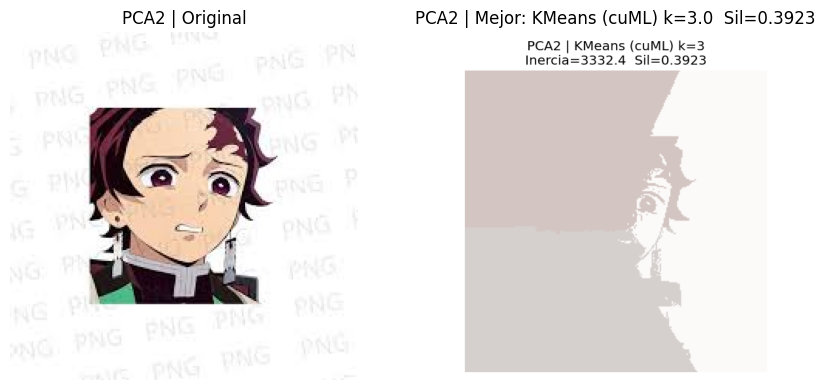

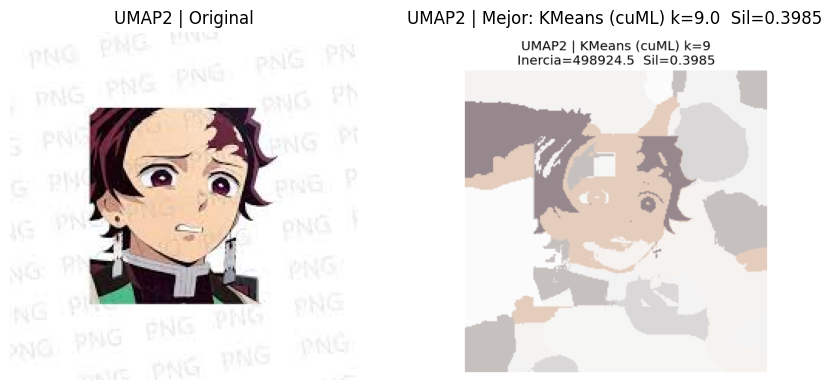

In [ ]:
# ============================================================
# 0) Imports, detección robusta de RAPIDS/cuML y fallbacks CPU
# ============================================================
import os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from skimage.io import imread
from skimage.color import rgb2lab, lab2rgb
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import silhouette_score as sk_silhouette
from sklearn.cluster import KMeans as skKMeans, MiniBatchKMeans as skMBKMeans, DBSCAN as skDBSCAN, SpectralClustering as skSpectral
from sklearn.decomposition import PCA as skPCA

# umap-learn (CPU)
try:
    import umap
    HAS_UMAP_CPU = True
except Exception:
    HAS_UMAP_CPU = False

# Flags por componente
USE_GPU = False
HAS_CUML = False
HAS_GPU_SIL = False
HAS_CU_PCA = False
HAS_CU_UMAP = False

try:
    import cupy as cp
    import cudf
    HAS_CUML = True
    USE_GPU = True

    # Clustering en GPU (suelen estar)
    from cuml.cluster import KMeans as cuKMeans
    from cuml.cluster import DBSCAN as cuDBSCAN

    # Silhouette en GPU (según versión)
    try:
        from cuml.metrics.cluster import silhouette_score as cu_silhouette
        HAS_GPU_SIL = True
    except Exception:
        HAS_GPU_SIL = False

    # PCA en GPU (puede faltar según versión)
    try:
        from cuml.decomposition import PCA as cuPCA
        HAS_CU_PCA = True
    except Exception:
        HAS_CU_PCA = False

    # UMAP en GPU (puede faltar según versión)
    try:
        from cuml.manifold import UMAP as cuUMAP
        HAS_CU_UMAP = True
    except Exception:
        HAS_CU_UMAP = False

except Exception:
    # Sin GPU/cuML; se usará CPU
    USE_GPU = False
    HAS_CUML = False
    HAS_GPU_SIL = False
    HAS_CU_PCA = False
    HAS_CU_UMAP = False

def _maybe_display(df):
    try:
        display(df)
    except Exception:
        print(df)

print("USE_GPU:", USE_GPU, "| HAS_CUML:", HAS_CUML)
print("HAS_GPU_SIL:", HAS_GPU_SIL)
print("HAS_CU_PCA:", HAS_CU_PCA, "| HAS_CU_UMAP:", HAS_CU_UMAP)
print("HAS_UMAP_CPU:", HAS_UMAP_CPU)

# ============================================================
# 1) Utilidades: features, métricas, reconstrucción, helpers
# ============================================================
def to_lab(img_rgb_float):
    return rgb2lab(img_rgb_float)  # float64

def build_features(image_rgb, lambda_xy=0.7, use_lab=True):
    """
    Construye X = [L, a, b, λx, λy] (o [R,G,B, λx, λy]) y devuelve (X, (H,W), img_float).
    """
    img = image_rgb.astype(np.float32)
    if img.max() > 1.0:
        img = img / 255.0
    H, W, _ = img.shape

    if use_lab:
        lab = to_lab(img).astype(np.float32)     # (H,W,3)
        color = lab.reshape(-1, 3)
    else:
        color = img.reshape(-1, 3)

    xs, ys = np.meshgrid(np.arange(W, dtype=np.float32),
                         np.arange(H, dtype=np.float32))
    coords = np.c_[lambda_xy*xs.ravel(), lambda_xy*ys.ravel()].astype(np.float32)

    X = np.c_[color, coords]   # (N,5)
    return X, (H, W), img

def scale_features(X):
    scaler = MinMaxScaler()
    Xs = scaler.fit_transform(X)
    return Xs, scaler

def gpu_arr(X):
    return cp.asarray(X) if USE_GPU else X

def silhouette_any(Xs, labels, sample_size=None, random_state=42):
    """
    Silhouette en GPU si está disponible; si no, sklearn en CPU.
    Admite muestreo para acelerar en datasets grandes.
    """
    uniq = np.unique(labels)
    if len(uniq) < 2:
        return np.nan

    if (sample_size is not None) and (sample_size < len(labels)):
        rng = np.random.default_rng(random_state)
        idx = rng.choice(len(labels), size=sample_size, replace=False)
        Xs_, y_ = Xs[idx], labels[idx]
    else:
        Xs_, y_ = Xs, labels

    if USE_GPU and HAS_GPU_SIL:
        try:
            return float(cu_silhouette(cp.asarray(Xs_), cp.asarray(y_)))
        except Exception:
            pass
    return float(sk_silhouette(Xs_, y_))

def seg_from_labels(labels, H, W, image_rgb, use_lab=True):
    """
    Reconstruye imagen segmentada promediando el color original por clúster.
    Si use_lab=True, promedia en L*a*b* y reconvierte a RGB.
    """
    img = image_rgb.astype(np.float32)
    if img.max() > 1.0:
        img = img / 255.0
    base = to_lab(img).astype(np.float32) if use_lab else img
    flat = base.reshape(-1, 3)

    K = int(labels.max()) + 1
    cents = []
    for k in range(K):
        m = (labels == k)
        cents.append(flat[m].mean(axis=0) if m.any() else flat.mean(axis=0))
    cents = np.vstack(cents).astype(np.float32)

    seg_flat = cents[labels]
    seg_lab = seg_flat.reshape(H, W, 3)
    seg_rgb = lab2rgb(seg_lab) if use_lab else seg_lab
    return np.clip(seg_rgb, 0, 1)

def save_seg(fig_img, title, out_path):
    plt.figure(figsize=(5,5))
    plt.imshow(fig_img)
    plt.title(title)
    plt.axis('off')
    plt.savefig(out_path, bbox_inches="tight", dpi=120)
    plt.close()

# ============================================================
# 2) Configuración del experimento (ajusta aquí)
# ============================================================
IMAGE_PATH = "tanjiro.jpeg"   # <-- Ajusta a tu ruta/imagen
OUT_DIR = "seg_dimreduce_all"
os.makedirs(OUT_DIR, exist_ok=True)

KS = [3, 5, 7, 9]        # valores de k a comparar
LAMBDA_XY = 0.7          # compactación espacial (tipo SLIC)
USE_LAB = True           # color perceptual
SIL_SAMPLE = None        # e.g., 10000 para acelerar en imágenes grandes
RANDOM_STATE = 42

# DBSCAN (no depende de k; ajusta según imagen)
DBSCAN_EPS = 0.35
DBSCAN_MIN_SAMPLES = 50

# Spectral Clustering (CPU) — cuidado con el costo en imágenes grandes
SPECTRAL_N_NEIGHBORS = 10
SPECTRAL_ASSIGN_LABELS = "kmeans"

# Parámetros de reducción (2D) — PCA / UMAP
PCA_NCOMP = 2
UMAP_N_NEIGHBORS = 30
UMAP_MIN_DIST = 0.15

# Espacios a evaluar (requerido por el enunciado)
ESPACIOS = ["PCA2", "UMAP2"]
# Si quieres baseline sin reducción, agrega: "RAW"

# ============================================================
# 3) Carga imagen y features base (RAW: 5D) + escalado
# ============================================================
image = imread(IMAGE_PATH)
X_raw, (H, W), image_f = build_features(image, lambda_xy=LAMBDA_XY, use_lab=USE_LAB)
Xs_raw, scaler_raw = scale_features(X_raw)  # (N,5)

# ============================================================
# 4) Reducción a 2D con detección por componente (GPU/CPU)
# ============================================================
# =================
# Reducción a 2D
# =================
PCA_NCOMP = 2
UMAP_N_NEIGHBORS = 30
UMAP_MIN_DIST = 0.15
RANDOM_STATE = 42

def reduce_space(Xs, space_name):
    """
    space_name ∈ {"RAW","PCA2","UMAP2"}.
    - RAW: devuelve Xs sin reducir (baseline).
    - PCA2: usa cuPCA si existe; si no, sklearn PCA (con fallback sin random_state).
    - UMAP2: usa cuUMAP si existe; si no, umap-learn CPU (con fallback sin random_state).
    """
    if space_name == "RAW":
        return Xs

    if space_name == "PCA2":
        # GPU: cuPCA suele NO aceptar random_state en algunas versiones
        if USE_GPU and HAS_CU_PCA:
            try:
                Z = cuPCA(n_components=PCA_NCOMP, random_state=RANDOM_STATE).fit_transform(gpu_arr(Xs))
            except TypeError:
                Z = cuPCA(n_components=PCA_NCOMP).fit_transform(gpu_arr(Xs))
            return cp.asnumpy(Z)
        else:
            # sklearn PCA puede usar random_state solo con svd_solver='randomized'
            try:
                pca = skPCA(n_components=PCA_NCOMP, svd_solver='randomized', random_state=RANDOM_STATE)
                return pca.fit_transform(Xs)
            except TypeError:
                return skPCA(n_components=PCA_NCOMP).fit_transform(Xs)

    if space_name == "UMAP2":
        if USE_GPU and HAS_CU_UMAP:
            try:
                um = cuUMAP(n_components=2, n_neighbors=UMAP_N_NEIGHBORS,
                            min_dist=UMAP_MIN_DIST, random_state=RANDOM_STATE)
            except TypeError:
                um = cuUMAP(n_components=2, n_neighbors=UMAP_N_NEIGHBORS,
                            min_dist=UMAP_MIN_DIST)
            Z = um.fit_transform(gpu_arr(Xs))
            return cp.asnumpy(Z)
        else:
            assert HAS_UMAP_CPU, "UMAP no disponible. Instala con: pip install umap-learn"
            try:
                um = umap.UMAP(n_components=2, n_neighbors=UMAP_N_NEIGHBORS,
                               min_dist=UMAP_MIN_DIST, random_state=RANDOM_STATE)
            except TypeError:
                um = umap.UMAP(n_components=2, n_neighbors=UMAP_N_NEIGHBORS,
                               min_dist=UMAP_MIN_DIST)
            return um.fit_transform(Xs)

    raise ValueError(f"Espacio no soportado: {space_name}")
# ============================================================
# 5) Wrappers de clustering por método (GPU/CPU)
# ============================================================
def run_kmeans(Z, k):
    if USE_GPU:
        km = cuKMeans(n_clusters=k, n_init='auto', random_state=RANDOM_STATE)
        labels = km.fit_predict(gpu_arr(Z))
        labels = cp.asnumpy(labels)
        inertia = float(km.inertia_)
        return labels, inertia, "KMeans (cuML)"
    else:
        km = skKMeans(n_clusters=k, n_init='auto', random_state=RANDOM_STATE)
        labels = km.fit_predict(Z)
        inertia = float(km.inertia_)
        return labels, inertia, "KMeans (CPU)"

def run_minibatch(Z, k):
    mbk = skMBKMeans(n_clusters=k, random_state=RANDOM_STATE, batch_size=2048)
    labels = mbk.fit_predict(Z)
    inertia = float(mbk.inertia_)
    return labels, inertia, "MiniBatchKMeans (CPU)"

def run_spectral(Z, k):
    sp = skSpectral(n_clusters=k,
                    affinity='nearest_neighbors',
                    n_neighbors=SPECTRAL_N_NEIGHBORS,
                    assign_labels=SPECTRAL_ASSIGN_LABELS,
                    random_state=RANDOM_STATE)
    labels = sp.fit_predict(Z)
    return labels, np.nan, "Spectral (CPU)"  # sin inercia

def run_dbscan(Z):
    if USE_GPU:
        db = cuDBSCAN(eps=DBSCAN_EPS, min_samples=DBSCAN_MIN_SAMPLES)
        labels = db.fit_predict(gpu_arr(Z))
        labels = cp.asnumpy(labels)
        metodo = "DBSCAN (cuML)"
    else:
        db = skDBSCAN(eps=DBSCAN_EPS, min_samples=DBSCAN_MIN_SAMPLES, n_jobs=-1)
        labels = db.fit_predict(Z)
        metodo = "DBSCAN (CPU)"
    valid = labels[labels != -1]
    n_clust = len(np.unique(valid)) if valid.size > 0 else 0
    sil = silhouette_any(Z[labels != -1], labels[labels != -1], sample_size=SIL_SAMPLE) if n_clust >= 2 else np.nan
    return labels, np.nan, metodo, n_clust, sil

# ============================================================
# 6) Experimento: por espacio reducido y método
# ============================================================
results = []

for space in ESPACIOS:
    print(f"\n=== Reducción: {space} ===")
    Z = reduce_space(Xs_raw, space)  # (N,2) o (N,5 si RAW)

    # Métodos que dependen de k
    for k in KS:
        # KMeans
        t0 = time.time()
        labels, inertia, metodo = run_kmeans(Z, k)
        sil = silhouette_any(Z, labels, sample_size=SIL_SAMPLE, random_state=RANDOM_STATE)
        seg = seg_from_labels(labels, H, W, image, use_lab=USE_LAB)
        out_png = os.path.join(OUT_DIR, f"{space}_kmeans_k{k}.png")
        save_seg(seg, f"{space} | {metodo} k={k}\nInercia={inertia:.1f}  Sil={sil:.4f}", out_png)
        results.append(dict(Espacio=space, Metodo=metodo, k=k, Inercia=inertia,
                            Silhouette=sil, Clusters=(labels.max()+1),
                            Tiempo_s=time.time() - t0, PNG=out_png))

        # MiniBatchKMeans (CPU)
        t0 = time.time()
        labels, inertia, metodo = run_minibatch(Z, k)
        sil = silhouette_any(Z, labels, sample_size=SIL_SAMPLE, random_state=RANDOM_STATE)
        seg = seg_from_labels(labels, H, W, image, use_lab=USE_LAB)
        out_png = os.path.join(OUT_DIR, f"{space}_minibatch_k{k}.png")
        save_seg(seg, f"{space} | {metodo} k={k}\nInercia={inertia:.1f}  Sil={sil:.4f}", out_png)
        results.append(dict(Espacio=space, Metodo=metodo, k=k, Inercia=inertia,
                            Silhouette=sil, Clusters=(labels.max()+1),
                            Tiempo_s=time.time() - t0, PNG=out_png))

        # Spectral (CPU)
        t0 = time.time()
        try:
            labels, inertia, metodo = run_spectral(Z, k)
            sil = silhouette_any(Z, labels, sample_size=SIL_SAMPLE, random_state=RANDOM_STATE)
            seg = seg_from_labels(labels, H, W, image, use_lab=USE_LAB)
            out_png = os.path.join(OUT_DIR, f"{space}_spectral_k{k}.png")
            save_seg(seg, f"{space} | {metodo} k={k}\nSil={sil:.4f}", out_png)
            results.append(dict(Espacio=space, Metodo=metodo, k=k, Inercia=np.nan,
                                Silhouette=sil, Clusters=(labels.max()+1),
                                Tiempo_s=time.time() - t0, PNG=out_png))
        except Exception as e:
            print(f"Spectral falló en {space}, k={k}: {e}")

    # DBSCAN (sin k)
    t0 = time.time()
    labels, inertia, metodo, n_clust, sil = run_dbscan(Z)

    # Para visualizar, asigna el ruido (-1) al clúster 0 (opcional; solo para colorear algo)
    vis_labels = labels.copy()
    if (vis_labels == -1).any():
        nonneg = vis_labels[vis_labels != -1]
        shift = nonneg.min() if nonneg.size > 0 else 0
        vis_labels[vis_labels == -1] = shift

    seg = seg_from_labels(vis_labels, H, W, image, use_lab=USE_LAB)
    out_png = os.path.join(OUT_DIR, f"{space}_dbscan.png")
    title = f"{space} | {metodo} clusters(valid)={n_clust}" + (f"  Sil(valid)={sil:.4f}" if not np.isnan(sil) else "")
    save_seg(seg, title, out_png)

    results.append(dict(Espacio=space, Metodo=metodo, k=None, Inercia=np.nan,
                        Silhouette=sil, Clusters=n_clust, Tiempo_s=time.time() - t0, PNG=out_png))

# ============================================================
# 7) Tabla comparativa y resumen visual
# ============================================================
df = pd.DataFrame(results, columns=["Espacio","Metodo","k","Inercia","Silhouette","Clusters","Tiempo_s","PNG"])
print("\n=== Resultados comparativos (ordenados) ===")
_m = df.sort_values(["Espacio","Metodo","k"], na_position="last")
_m = _m.reset_index(drop=True)
_maybe_display(_m)
print("\nImágenes guardadas en:", os.path.abspath(OUT_DIR))

# Vista rápida: mejor Silhouette por espacio (solo métodos con k)
for space in ESPACIOS:
    sub = df[(df["Espacio"]==space) & df["Metodo"].str.contains("KMeans")]
    if not sub.empty:
        best = sub.loc[sub["Silhouette"].idxmax()]
        img = plt.imread(best["PNG"])
        plt.figure(figsize=(9,4))
        plt.subplot(1,2,1); plt.imshow(image_f); plt.title(f"{space} | Original"); plt.axis('off')
        plt.subplot(1,2,2); plt.imshow(img); plt.title(f"{space} | Mejor: {best['Metodo']} k={best['k']}  Sil={best['Silhouette']:.4f}")
        plt.axis('off'); plt.tight_layout(); plt.show()
